In [1]:
import matplotlib.pyplot as plt
import arviz as az
import seaborn as sns
from arviz import InferenceData  # ringdown uses arviz InferenceData objects
from pathlib import Path
import ringdown as rd
from ringdown.result import Result
import numpy as np

import re
from io import BytesIO
from PIL import Image

/home/selmavangstein/miniconda3/envs/ringdown/lib/python3.11/site-packages/ringdown/data.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import qnm

In [3]:
qnm.download_data()

Destination path /home/selmavangstein/.cache/qnm/data-0.4.0.tar.bz2 already exists, use overwrite=True to force an overwrite.


In [4]:
grav220 = qnm.modes_cache(-2,2,2,0)
grav220(a=0.7)[0] # freq of this mode bh w m=1
# use it to plot the expected amplitude decay
# stein qnm paper

np.complex128(0.532600243551018-0.08079287315500867j)

In [25]:
def compute_expected_decay(res, mode_l, mode_m, mode_n, mode_index, start_ref, t_array):
    """
    Compute expected amplitude decay based on posterior samples
    res: Result object
    mode_l, mode_m, mode_n, mode_p: mode indices (e.g., 2, 2, 0, 0 for 220)
    start_ref: reference start time where amplitude is measured
    t_array: array of times to evaluate decay
    """
    qnm_mode = qnm.modes_cache(-2, mode_l, mode_m, mode_n)

    a_ref = np.array(res.posterior['a'].isel(mode=mode_index)).flatten()
    m_post = res.posterior['m'].values.flatten()
    chi_post = res.posterior['chi'].values.flatten()

    decay_curves = []
    for m, chi, a0 in zip(m_post, chi_post, a_ref):
        chi = float(chi)
        m = float(m)
        a0 = float(a0)
        omega, A_qnm, C = qnm_mode(a=chi)
        freq = omega.real / (2 * np.pi)  # Frequency in Hz 
        gamma = -omega.imag  # Damping rate

        # Expected amplitude: A(t) = A0 * exp(-gamma * (t - t_ref) / M)
        # Convert time difference to units of M
        dt = (t_array - start_ref)  # Already in M units
        expected_a = a0 * np.exp(-gamma * dt)
        decay_curves.append(expected_a)

    decay_curves = np.array(decay_curves)

    return {
        'median': np.median(decay_curves, axis=0),
        'p05': np.percentile(decay_curves, 5, axis=0),
        'p95': np.percentile(decay_curves, 95, axis=0),
    }

In [26]:
# Extract parameters from your configuration
num_modes = [1, 2]
start_offsets = [5, 6, 7, 8, 9, 10, 10.5, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

# Configuration
FIT_DIR = Path("./fitresults")
VAR_NAMES = ['m', 'chi']
PLOT_DIR = Path("./fitresults_plots")

# Parse filenames - handles format like start_105 for 10.5
pattern = re.compile(r".*modes[_-]?(\d+).*start[_-]?(\d+).*\.nc$", re.IGNORECASE)
files = {}

for p in FIT_DIR.glob("*.nc"):
    m = pattern.match(p.name)
    if not m:
        continue
    modes = int(m.group(1))
    start_int = int(m.group(2))
    # Convert: 105 -> 10.5, 4 -> 4.0, etc.
    start = start_int / 10.0 if start_int >= 100 else float(start_int)
    files[(start, modes)] = p

if not files:
    raise FileNotFoundError(f"No matching result files found in {FIT_DIR}")

print(f"Found {len(files)} result files")

nrows = len(start_offsets)
ncols = len(num_modes)

Found 33 result files



Saved plot to fitresults_plots/amplitude_vs_start_time.png


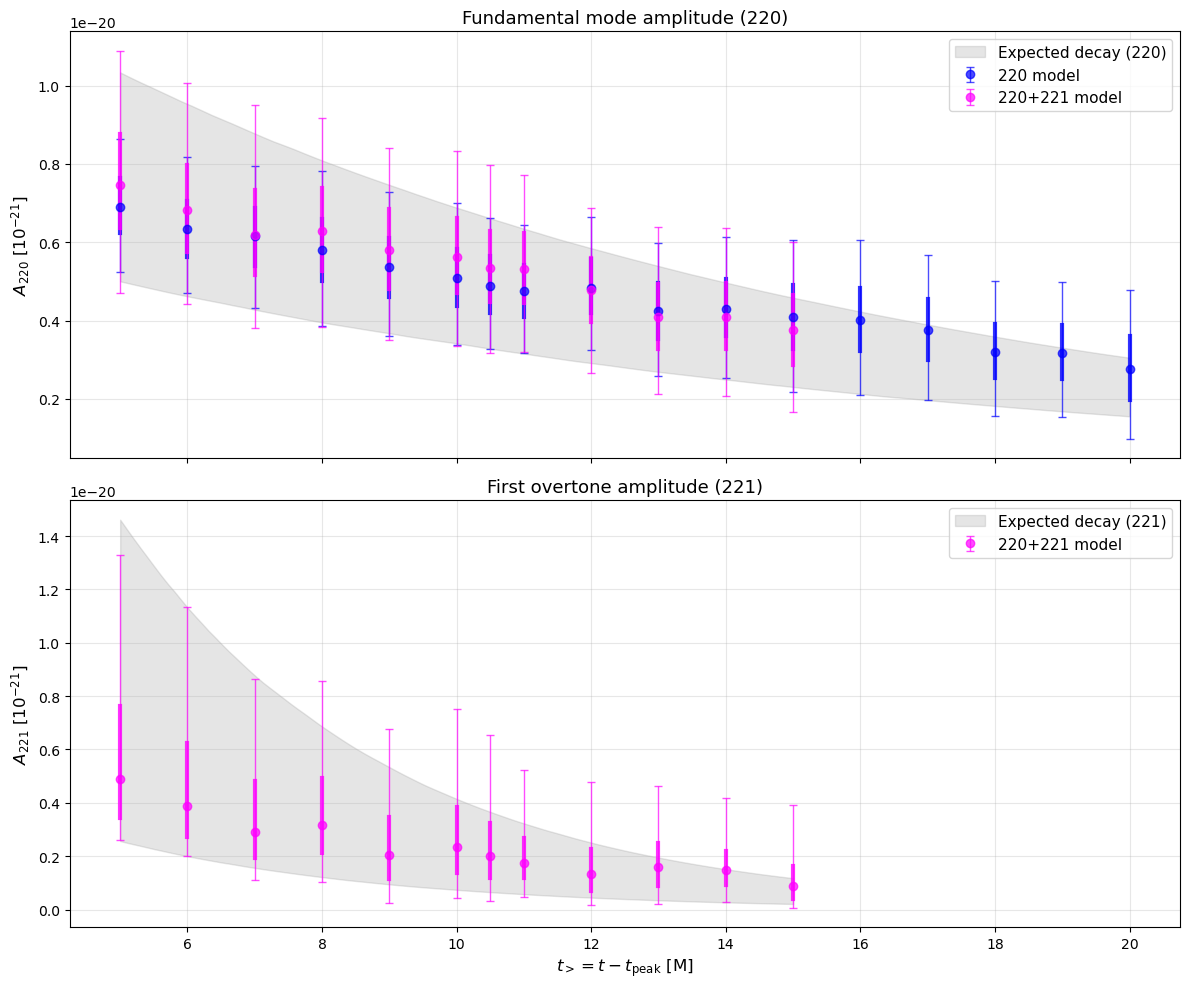

In [29]:
# Create figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10),sharex=True)

colors = {1: 'blue', 2: 'magenta'}
labels = {1: '220 model', 2: '220+221 model'}

# Collect data for plotting
data_1mode = {'starts': [], 'a220_med': [], 'a220_lo': [], 'a220_hi': [], 
              'a220_25': [], 'a220_75': []}
data_2mode = {'starts': [], 'a220_med': [], 'a220_lo': [], 'a220_hi': [],
              'a220_25': [], 'a220_75': [],
              'a221_med': [], 'a221_lo': [], 'a221_hi': [],
              'a221_25': [], 'a221_75': []}

for mode_count in num_modes:
    
    for start in sorted(start_offsets):
        key = (start, mode_count)
        if key not in files:
            continue
        
        try:
            res = Result.from_netcdf(files[key])
            available_modes = list(res.posterior['a'].coords['mode'].values)
            
            # Get amplitude for first mode (220)
            if len(available_modes) >= 1:
                a_220 = np.array(res.posterior['a'].isel(mode=0)).flatten()
                
                if mode_count == 1:
                    data_1mode['starts'].append(start)
                    data_1mode['a220_med'].append(np.median(a_220))
                    data_1mode['a220_lo'].append(np.percentile(a_220, 5))
                    data_1mode['a220_hi'].append(np.percentile(a_220, 95))
                    data_1mode['a220_25'].append(np.percentile(a_220, 25))
                    data_1mode['a220_75'].append(np.percentile(a_220, 75))
                else:
                    data_2mode['starts'].append(start)
                    data_2mode['a220_med'].append(np.median(a_220))
                    data_2mode['a220_lo'].append(np.percentile(a_220, 5))
                    data_2mode['a220_hi'].append(np.percentile(a_220, 95))
                    data_2mode['a220_25'].append(np.percentile(a_220, 25))
                    data_2mode['a220_75'].append(np.percentile(a_220, 75))
            
            # Get amplitude for second mode (221) if available
            if mode_count == 2 and len(available_modes) >= 2:
                a_221 = np.array(res.posterior['a'].isel(mode=1)).flatten()
                data_2mode['a221_med'].append(np.median(a_221))
                data_2mode['a221_lo'].append(np.percentile(a_221, 5))
                data_2mode['a221_hi'].append(np.percentile(a_221, 95))
                data_2mode['a221_25'].append(np.percentile(a_221, 25))
                data_2mode['a221_75'].append(np.percentile(a_221, 75))
            
        except Exception as e:
            print(f"Error processing modes={mode_count}, start={start}: {e}")
            continue

# Plot top panel: A_220 for both 1-mode and 2-mode
ax = axs[0]

if data_1mode['starts']:
    starts_1 = np.array(data_1mode['starts'])
    med_1 = np.array(data_1mode['a220_med'])
    lo_1 = np.array(data_1mode['a220_lo'])
    hi_1 = np.array(data_1mode['a220_hi'])
    p25_1 = np.array(data_1mode['a220_25'])
    p75_1 = np.array(data_1mode['a220_75'])

    # Plot with error bars
    ax.errorbar(starts_1, med_1, 
                yerr=[med_1 - lo_1, hi_1 - med_1],
                fmt='o', color=colors[1], label=labels[1], 
                linewidth=1, markersize=6, capsize=3, alpha=0.7)
    # Add thicker error bars for 25th-75th percentiles
    for i, s in enumerate(starts_1):
        ax.plot([s, s], [p25_1[i], p75_1[i]], 
               color=colors[1], linewidth=3, alpha=0.8)
        
    # Compute and plot expected decay for 1-mode
    ref_time = 10.5
    ref_key = (ref_time, 1) if (ref_time, 1) in files else (starts_1[-1], 1)
    if ref_key in files:
        res_ref = Result.from_netcdf(files[ref_key])
        t_decay = np.linspace(starts_1.min(), starts_1.max(), 100)
        decay_1 = compute_expected_decay(res_ref, 2, 2, 0, 0, ref_key[0], t_decay)
        ax.fill_between(t_decay, decay_1['p05'], decay_1['p95'], 
                       color='grey', alpha=0.2, label='Expected decay (220)')

if data_2mode['starts']:
    starts_2 = np.array(data_2mode['starts'])
    med_2 = np.array(data_2mode['a220_med'])
    lo_2 = np.array(data_2mode['a220_lo'])
    hi_2 = np.array(data_2mode['a220_hi'])
    p25_2 = np.array(data_2mode['a220_25'])
    p75_2 = np.array(data_2mode['a220_75'])
    
    ax.errorbar(starts_2, med_2,
                yerr=[med_2 - lo_2, hi_2 - med_2],
                fmt='o', color=colors[2], label=labels[2],
                linewidth=1, markersize=6, capsize=3, alpha=0.7)
    for i, s in enumerate(starts_2):
        ax.plot([s, s], [p25_2[i], p75_2[i]], 
               color=colors[2], linewidth=3, alpha=0.8)

ax.set_ylabel(r'$A_{220}$ [$10^{-21}$]', fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title("Fundamental mode amplitude (220)", fontsize=13)

# Plot bottom panel: A_221 for 2-mode only
ax = axs[1]
if data_2mode['starts'] and data_2mode['a221_med']:
    med_221 = np.array(data_2mode['a221_med'])
    lo_221 = np.array(data_2mode['a221_lo'])
    hi_221 = np.array(data_2mode['a221_hi'])
    p25_221 = np.array(data_2mode['a221_25'])
    p75_221 = np.array(data_2mode['a221_75'])
    
    ax.errorbar(starts_2, med_221,
                yerr=[med_221 - lo_221, hi_221 - med_221],
                fmt='o', color=colors[2], label=labels[2],
                linewidth=1, markersize=6, capsize=3, alpha=0.7)
    for i, s in enumerate(starts_2):
        ax.plot([s, s], [p25_221[i], p75_221[i]], 
               color=colors[2], linewidth=3, alpha=0.8)
        
    # Compute and plot expected decay for 221 mode
    ref_time = 6.0
    ref_key_221 = (6, 2) if (6, 2) in files else (starts_2[0], 2)
    if ref_key_221 in files:
        res_ref_221 = Result.from_netcdf(files[ref_key_221])
        t_decay_221 = np.linspace(starts_2.min(), starts_2.max(), 100)
        decay_221 = compute_expected_decay(res_ref_221, 2, 2, 1, 1, ref_key_221[0], t_decay_221)
        ax.fill_between(t_decay_221, decay_221['p05'], decay_221['p95'], 
                       color='grey', alpha=0.2, label='Expected decay (221)')

ax.set_xlabel(r'$t_> = t - t_{\mathrm{peak}}$ [M]', fontsize=12)
ax.set_ylabel(r'$A_{221}$ [$10^{-21}$]', fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title("First overtone amplitude (221)", fontsize=13)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'amplitude_vs_start_time.png', dpi=150, bbox_inches='tight')
print(f"\nSaved plot to {PLOT_DIR / 'amplitude_vs_start_time.png'}")
plt.show()